In [17]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import sys
import os

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../../../')) # 親ディレクトリをモジュール探索パスに追加
from src.VvGammaChart import (
    calculate_stab_basic_metrics,
    collect_vv_wtip_sweep_progress,
    plot_vv_gamma_contour_panel,
    postprocess_vv_gamma_cases,
    run_vv_wtip_stability_sweep,
)

In [35]:
base_vsp3_path = Path('../../models/BRGlider/BRGlider.0G.vsp3')
output_dir = Path('')

vv_values = np.linspace(0.001, 0.006, 11)
tip_deflections = np.linspace(0.0, 2.0, 11)

flight_condition = {
    'alpha_deg': 0.0,
    'mach': 0.0,
    'reynolds': 1.0e6,
}

geometry_config = {
    'lv': 4.5,          # x_ac_vtail - xcg, model length unit
    'wing_area': 18,
    'wing_span': 27,
    'xcg': 1.4,
    'wing_name': 'WingGeom',
    'vtail_name': 'VTailGeom',
    'n_span': 101,
    "vtail_area_scale_mode": "fixed_aspect_ratio",
}

# 以下の値は notebook の呼び出し形を示すための仮置きです。
mass = 100.0
inertia = {
    'Ixx': 1000.0,
    'Iyy': 75.0,
    'Izz': 1000.0,
    'Ixz': 0.0,
}

GRID_SIZE = 256
LEVELS = 256
METHOD = "linear"
FALLBACK_METHOD = "nearest"
SHOW_POINTS = False


COLORBAR_TICKS_BY_COLUMN = {
    # Column-name keyed examples:
    # "simple_turn_rate": np.linspace(-0.05, 0.05, 11),
    # "turn_trim_delta_r": np.linspace(-0.3, 0.3, 7),
    # "turn_trim_delta_r_per_beta": np.linspace(-20.0, 5.0, 6),
    "sixdof_roll_response_phi_rate_per_delta_r": np.linspace(-0.06,0.0,7),
    'simple_turn_rate': np.linspace(-0.06,0.00,7),
    "spiral_margin": np.linspace(-0.006,0.006,7),
}

# Set these to sequences such as np.linspace(...) when fixed axis ticks are desired.
VV_TICKS = np.linspace(0.001,0.006,6)
GAMMA_TICKS = np.linspace(0,8,9)

PANEL_KWARGS = dict(
    grid_size=GRID_SIZE,
    levels=LEVELS,
    method=METHOD,
    fallback_method=FALLBACK_METHOD,
    colorbar_ticks_by_column=COLORBAR_TICKS_BY_COLUMN,
    x_ticks=VV_TICKS,
    y_ticks=GAMMA_TICKS,
    show_points=SHOW_POINTS,
    show_colorbar=True,
)


## 0. パラメータ計算

In [19]:
sweep = collect_vv_wtip_sweep_progress(
    vv_values,
    tip_deflections,
    output_dir,
    gamma_semispan=13.5,
    include_incomplete_cases=False,
    output_csv_path=output_dir / 'vv_wtip_stability_sweep_progress.csv',
)
sweep.head()


,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,passed,vspaero_passed,error
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,True,True,
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,True,True,
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,True,True,
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,13.5,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,True,True,
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,13.5,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,True,True,


In [20]:

# results = postprocess_vv_gamma_cases(
#     sweep,
#     mass=mass,
#     inertia=inertia,
#     delta_r=math.radians(-10.0),
#     target_delta_phi=math.radians(1.0),
#     turn_trim_mode='gliding',
#     turn_trim_phi=math.radians(5.0),
#     t_final=99.0,
#     output_csv_path=output_dir / 'vv_gamma_metrics.csv',
#     history_output_dir=output_dir / '6dof_history',
#     write_6dof_history=False,
#     plot_6dof_history=False,
#     calculate_linear_lateral_response=True,
#     verbose=2,
# )
# results.head()


## 1. import と入力CSV

CSV は以下の順で探す。

1. notebook と同じディレクトリ
2. 親ディレクトリ以下の同名CSV

配置が異なる場合は `csv_path` を直接書き換える。

In [21]:
from pathlib import Path
import ast
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["mathtext.fontset"] = "stix"

# Repository root.  Adjust this if the notebook is moved.
sys.path.append(os.path.join("../../../"))
from src.VvGammaChart import plot_vv_gamma_contour_panel

csv_path = Path("vv_gamma_metrics.csv")

output_dir = Path("vv_gamma_chart_plots")
output_dir.mkdir(parents=True, exist_ok=True)

print("csv_path:", csv_path.resolve())
print("output_dir:", output_dir.resolve())

csv_path: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_metrics.csv
output_dir: C:\Users\mtkbirdman\OneDrive\Documents\OpenVSP\examples\notebooks\vv_gamma_chart\vv_gamma_chart_plots


## 2. CSV読込と前処理

`passed` 列がある場合は成功ケースだけをプロット対象にする。Vv-Gamma チャートには `Vv` と `Gamma_eff_deg` が必要である。

In [22]:
df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

required_axis_columns = {"Vv", "Gamma_eff_deg"}
missing_axis_columns = required_axis_columns - set(df.columns)
if missing_axis_columns:
    raise KeyError(f"vv_gamma_metrics.csv is missing Vv-Gamma axis column(s): {sorted(missing_axis_columns)}")

if "passed" in df.columns:
    if df["passed"].dtype == bool:
        passed_mask = df["passed"]
    else:
        passed_mask = df["passed"].astype(str).str.lower().isin(["true", "1", "yes"])
    df = df[passed_mask].copy().reset_index(drop=True)

print("rows:", len(df))
print("Vv range:", float(df["Vv"].min()), "to", float(df["Vv"].max()))
print("Gamma_eff_deg range:", float(df["Gamma_eff_deg"].min()), "to", float(df["Gamma_eff_deg"].max()))
print("columns:", len(df.columns))
df.head()

rows: 121
Vv range: 0.001 to 0.006
Gamma_eff_deg range: 0.0 to 9.692678823088029
columns: 392


,case,case_index,case_count,Vv,tip_deflection,case_dir,gamma_semispan,vsp3_path,deflection_csv_path,stab_path,...,turn_trim_coefficients_Cl,turn_trim_coefficients_Cm,turn_trim_coefficients_Cn,turn_trim_residuals_force_x,turn_trim_residuals_force_y,turn_trim_residuals_force_z,turn_trim_residuals_moment_l,turn_trim_residuals_moment_m,turn_trim_residuals_moment_n,turn_trim_height_residual
0,vv_0p00100_wtip_0p00000,1,121,0.001,0.0,vv_0p00100_wtip_0p00000,13.5,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,vv_0p00100_wtip_0p00000\vv_0p00100_wtip_0p0000...,...,2.006097e-03,-4.489126e-06,5.711504e-03,1.352898e-04,4.363791e-04,2.028369e-05,2.006097e-03,-4.489126e-06,5.711504e-03,0.024433
1,vv_0p00100_wtip_0p20000,2,121,0.001,0.2,vv_0p00100_wtip_0p20000,13.5,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,vv_0p00100_wtip_0p20000\vv_0p00100_wtip_0p2000...,...,6.180476e-04,-6.110854e-07,2.371237e-03,7.216559e-05,3.694636e-04,3.080168e-06,6.180476e-04,-6.110854e-07,2.371237e-03,0.025572
2,vv_0p00100_wtip_0p40000,3,121,0.001,0.4,vv_0p00100_wtip_0p40000,13.5,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,vv_0p00100_wtip_0p40000\vv_0p00100_wtip_0p4000...,...,3.328119e-13,9.086482e-15,3.873941e-14,1.545911e-12,1.509286e-12,-3.784405e-14,3.328119e-13,9.086482e-15,3.873941e-14,0.024458
3,vv_0p00100_wtip_0p60000,4,121,0.001,0.6,vv_0p00100_wtip_0p60000,13.5,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,vv_0p00100_wtip_0p60000\vv_0p00100_wtip_0p6000...,...,2.654127e-15,3.729655e-17,3.165870e-16,1.113345e-14,5.139754e-15,2.577933e-15,2.654127e-15,3.729655e-17,3.165870e-16,0.024415
4,vv_0p00100_wtip_0p80000,5,121,0.001,0.8,vv_0p00100_wtip_0p80000,13.5,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,vv_0p00100_wtip_0p80000\vv_0p00100_wtip_0p8000...,...,9.931292e-17,8.239937e-18,1.040834e-17,4.608055e-16,1.160070e-16,-7.218212e-16,9.931292e-17,8.239937e-18,1.040834e-17,0.024408


## 3. `ConGrp_*` と $\delta_e, \delta_a, \delta_r$ の対応

`ConGrp_1`, `ConGrp_2`, `ConGrp_3` は、モデル内の Control Surface Group の順番に依存する。CSV の `control_groups` から対応を読む。

In [23]:
def read_control_groups(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    return ast.literal_eval(str(value))

control_groups = {}
if "control_groups" in df.columns and df["control_groups"].notna().any():
    control_groups = read_control_groups(df.loc[df["control_groups"].notna(), "control_groups"].iloc[0])

# Fallback is the G103A convention used in the current model.
delta_to_congrp = {
    "delta_a": "ConGrp_1",
    "delta_e": "ConGrp_2",
    "delta_r": "ConGrp_3",
}

for congrp, group_name in control_groups.items():
    name = str(group_name).upper()
    if "AILERON" in name:
        delta_to_congrp["delta_a"] = congrp
    elif "ELEVATOR" in name:
        delta_to_congrp["delta_e"] = congrp
    elif "RUDDER" in name:
        delta_to_congrp["delta_r"] = congrp

print("control_groups:", control_groups)
print("delta_to_congrp:", delta_to_congrp)

control_groups: {'ConGrp_1': 'AILERON_GROUP', 'ConGrp_2': 'ELEVATOR_GROUP', 'ConGrp_3': 'RUDDER_GROUP'}
delta_to_congrp: {'delta_a': 'ConGrp_1', 'delta_e': 'ConGrp_2', 'delta_r': 'ConGrp_3'}


In [24]:

def save_figure(fig, stem):
    fig.tight_layout()
    fig.savefig(output_dir / f"{stem}.png", dpi=200, bbox_inches="tight")
    fig.savefig(output_dir / f"{stem}.pdf", bbox_inches="tight")


## 5. Base 空力係数

3行2列で、左列を $C_L, C_Y, C_D$、右列を $C_l, C_m, C_n$ にする。

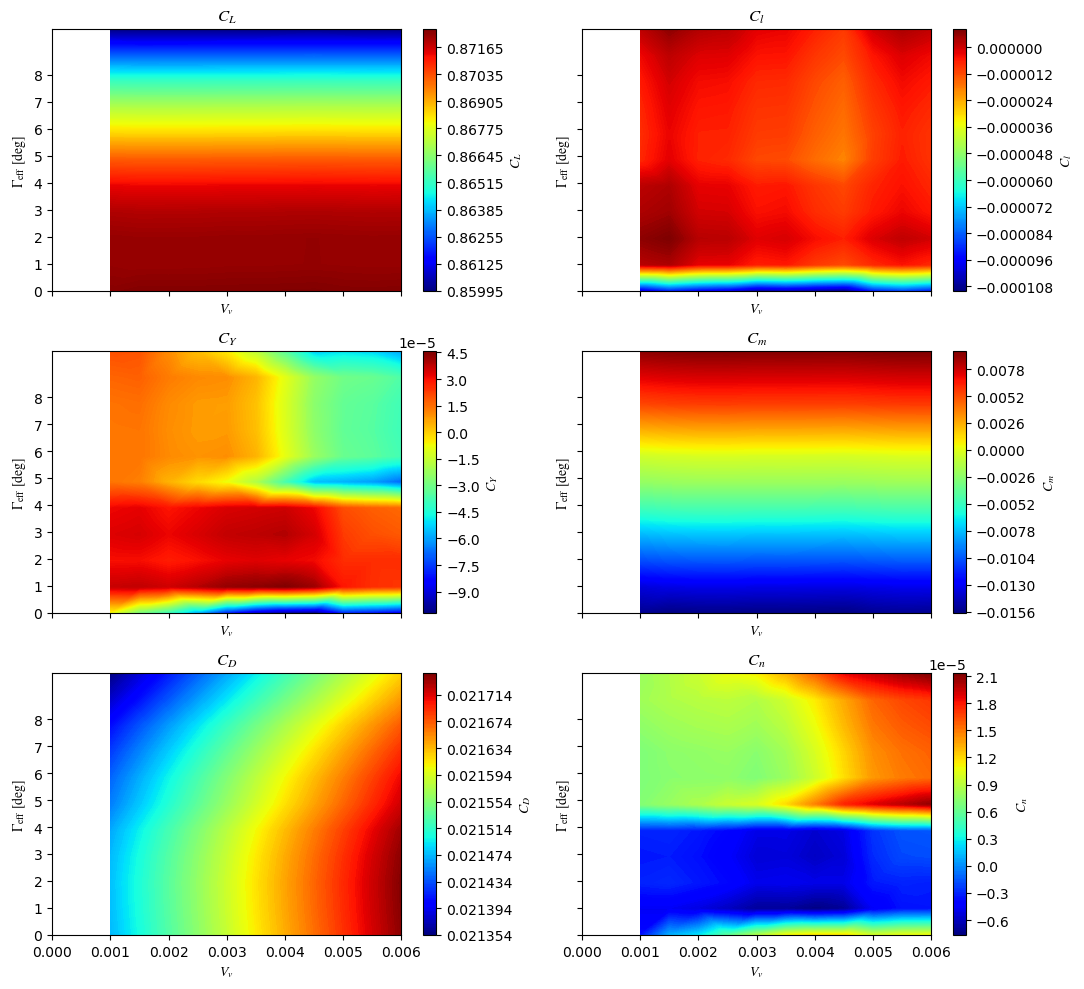

In [25]:
base_panels = [
    ("CL_Base", r"$C_L$"),
    ("CMl_Base", r"$C_l$"),
    ("CY_Base", r"$C_Y$"),
    ("CMm_Base", r"$C_m$"),
    ("CD_Base", r"$C_D$"),
    ("CMn_Base", r"$C_n$"),
]

fig, axes = plt.subplots(3, 2, figsize=(11, 10), sharex=True, sharey=True)
for ax, (column, label) in zip(axes.flat, base_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_base_coefficients")
plt.show()

## 6. 縦の空力微係数

列は左から $C_L, C_D, C_m$、行は上から $\alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

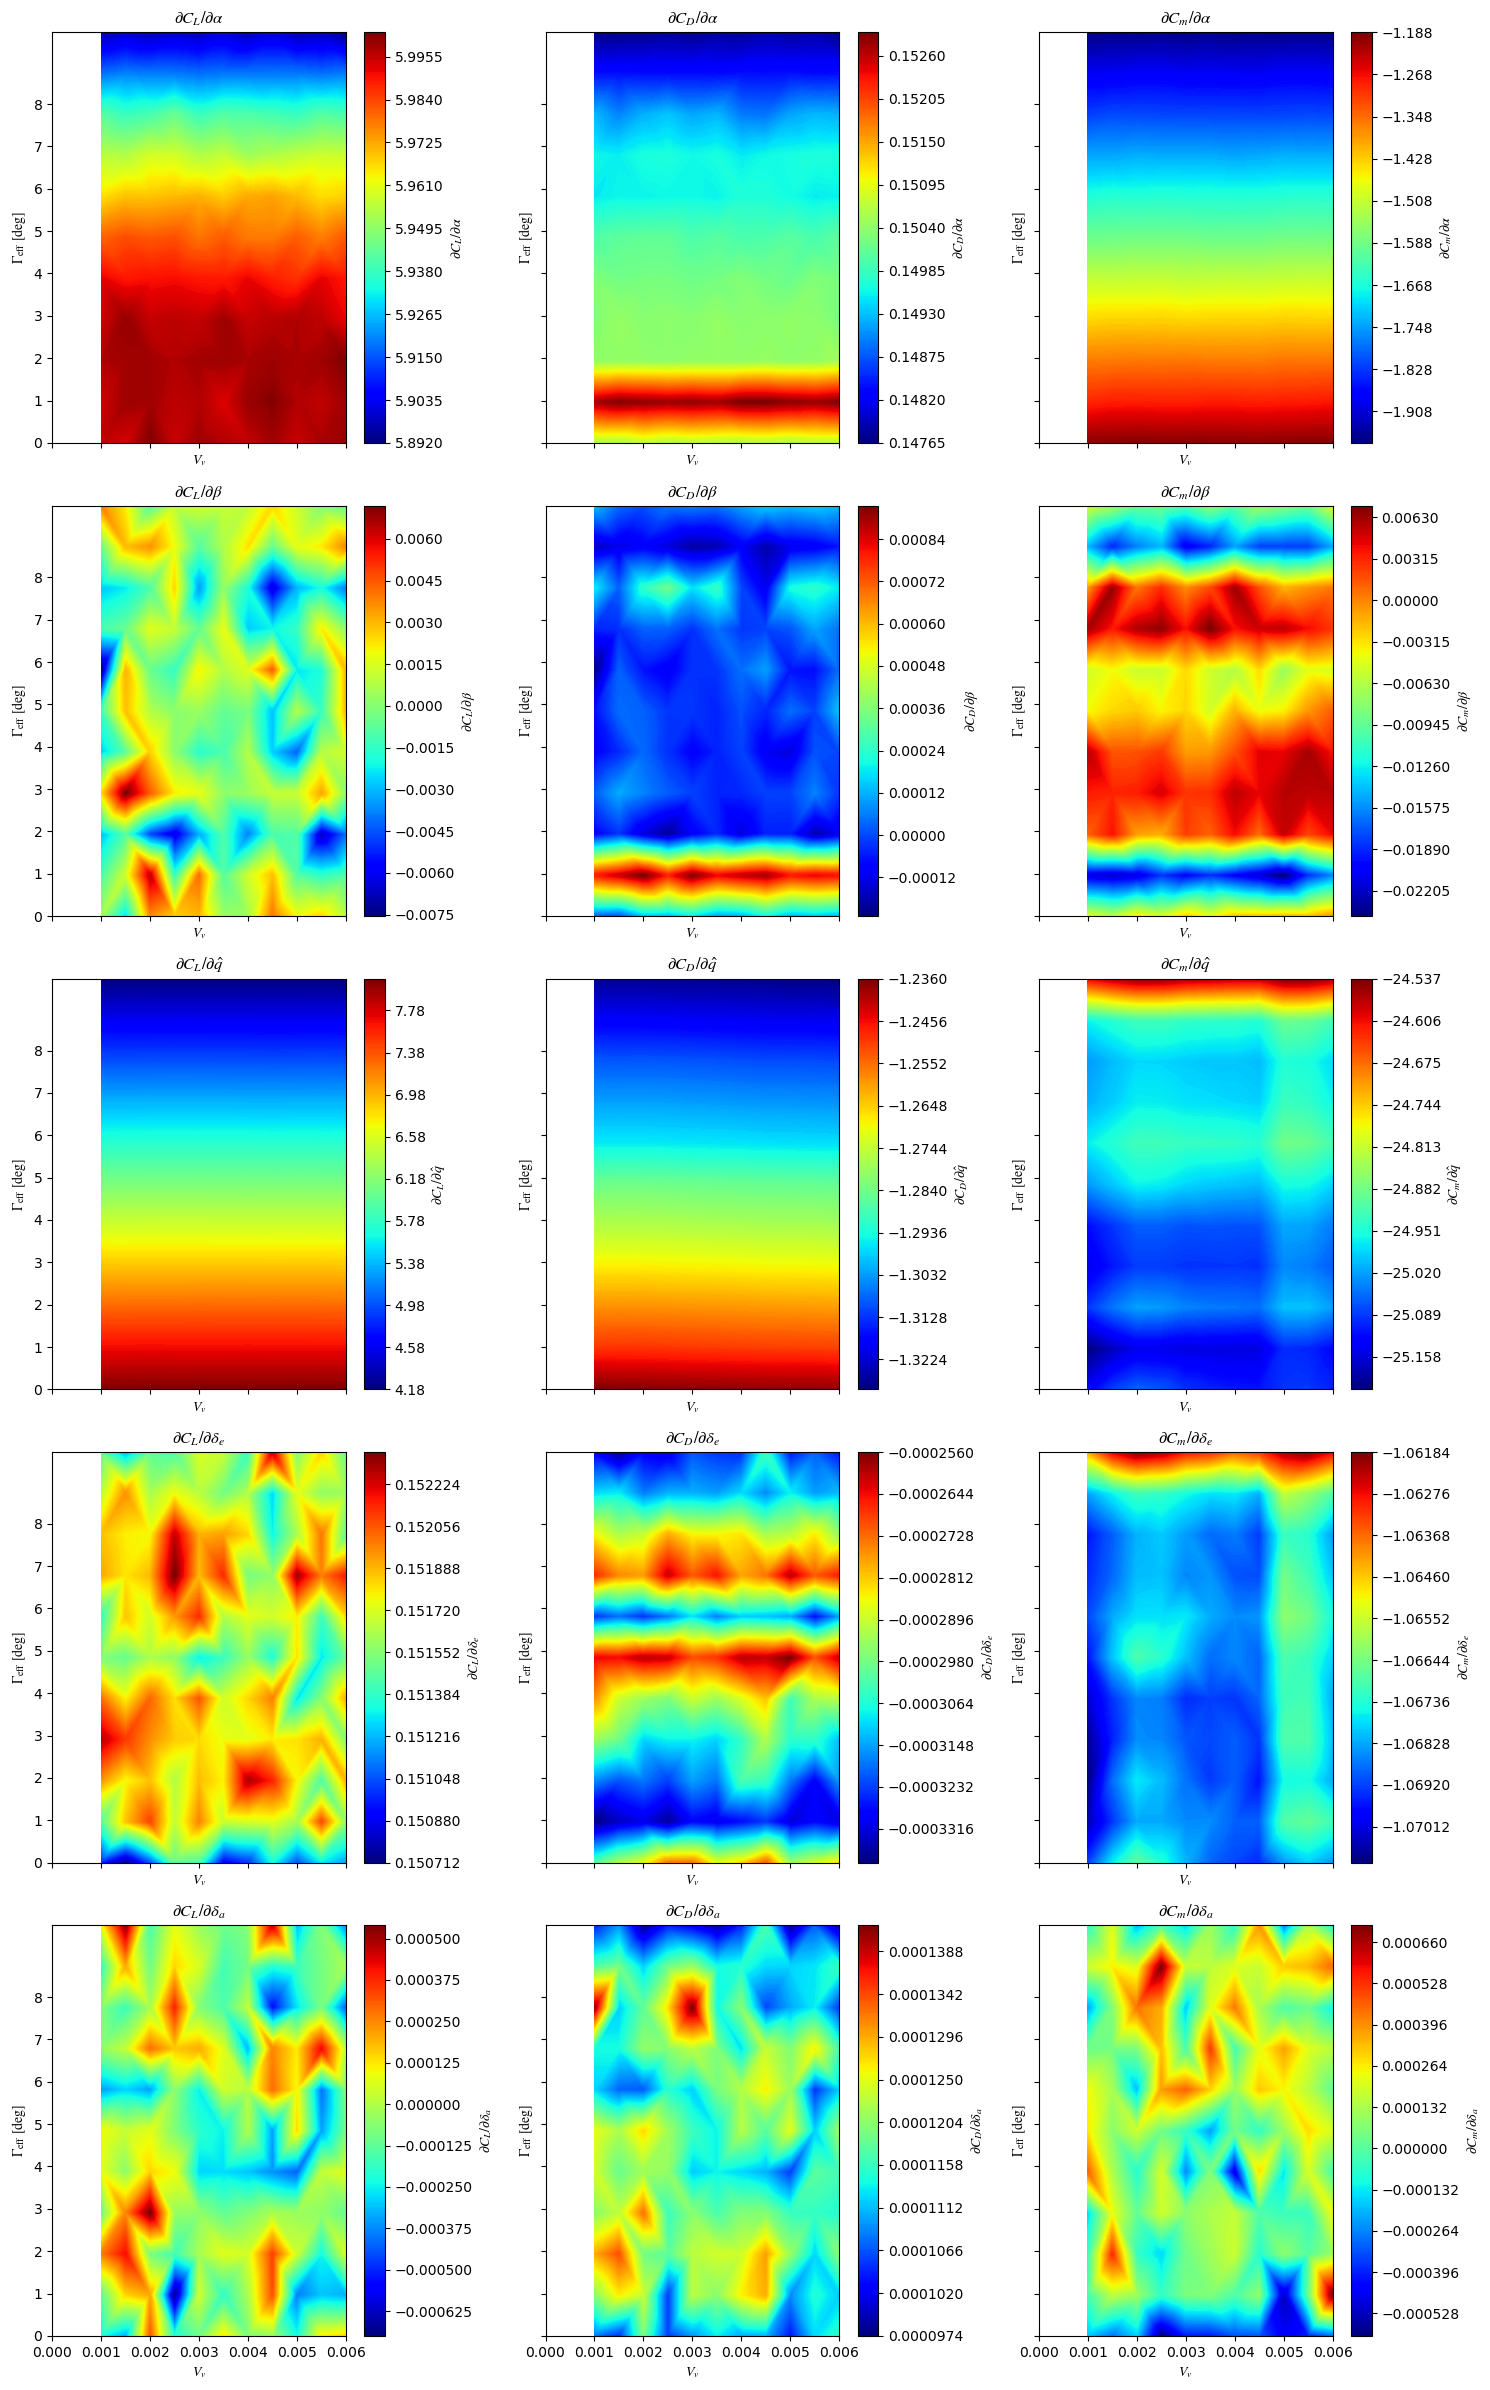

In [26]:
derivative_rows = [
    ("Alpha", r"\alpha"),
    ("Beta", r"\beta"),
    # ("p", r"\hat{p}"),
    ("q", r"\hat{q}"),
    # ("r", r"\hat{r}"),
    (delta_to_congrp["delta_e"], r"\delta_e"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    # (delta_to_congrp["delta_r"], r"\delta_r"),
]

longitudinal_columns = [
    ("CL", r"C_L"),
    ("CD", r"C_D"),
    ("CMm", r"C_m"),
]

fig, axes = plt.subplots(len(derivative_rows), len(longitudinal_columns), figsize=(15, 24), sharex=True, sharey=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(longitudinal_columns):
        column = f"{prefix}_{suffix}"
        label = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_vv_gamma_contour_panel(df, column, ax=axes[row_index, col_index], label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_longitudinal_derivatives")
plt.show()

## 7. 横・方向の空力微係数

列は左から $C_Y, C_l, C_n$、行は上から $\alpha, \beta, \hat p, \hat q, \hat r, \delta_e, \delta_a, \delta_r$ とする。

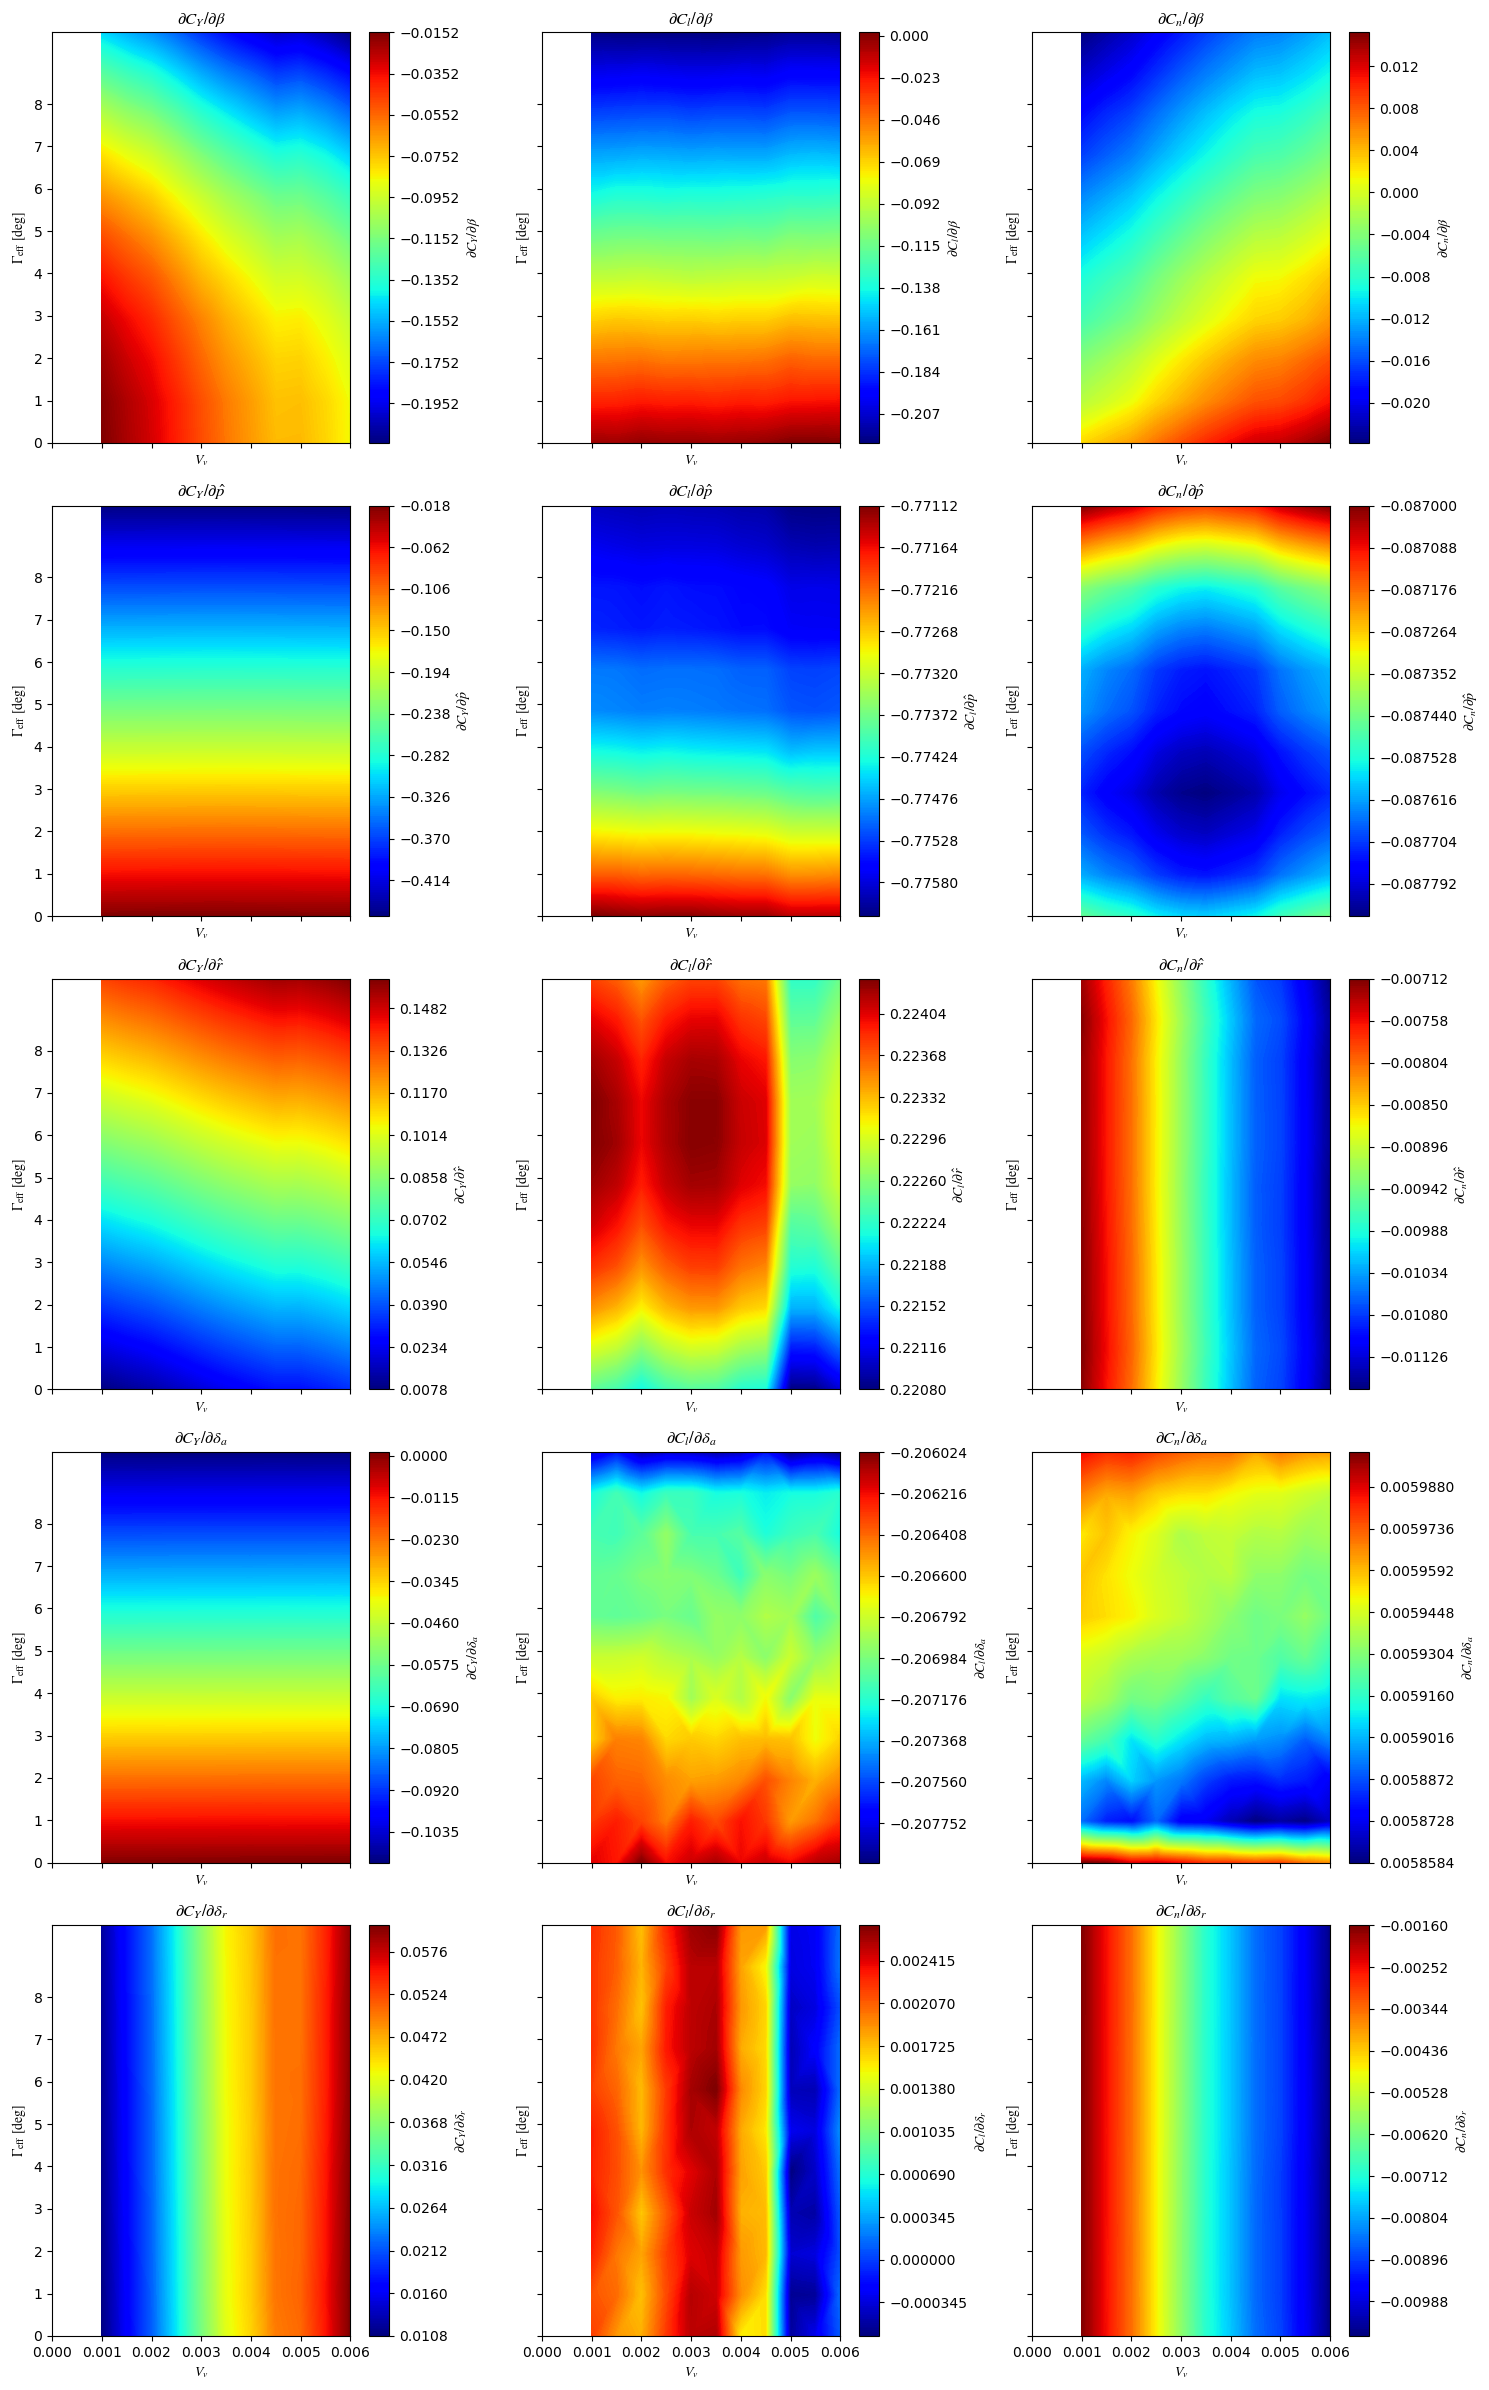

In [27]:
lateral_columns = [
    ("CY", r"C_Y"),
    ("CMl", r"C_l"),
    ("CMn", r"C_n"),
]
derivative_rows = [
    ("Beta", r"\beta"),
    ("p", r"\hat{p}"),
    ("r", r"\hat{r}"),
    (delta_to_congrp["delta_a"], r"\delta_a"),
    (delta_to_congrp["delta_r"], r"\delta_r"),
]

fig, axes = plt.subplots(len(derivative_rows), len(lateral_columns), figsize=(15, 24), sharex=True, sharey=True)

for row_index, (suffix, variable_label) in enumerate(derivative_rows):
    for col_index, (prefix, coefficient_label) in enumerate(lateral_columns):
        column = f"{prefix}_{suffix}"
        label = rf"$\partial {coefficient_label}/\partial {variable_label}$"
        plot_vv_gamma_contour_panel(df, column, ax=axes[row_index, col_index], label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_lateral_derivatives")
plt.show()

## 8. ラダーのみ旋回の評価指標

ラダーのみ旋回でよく見る指標をまとめて描画する。

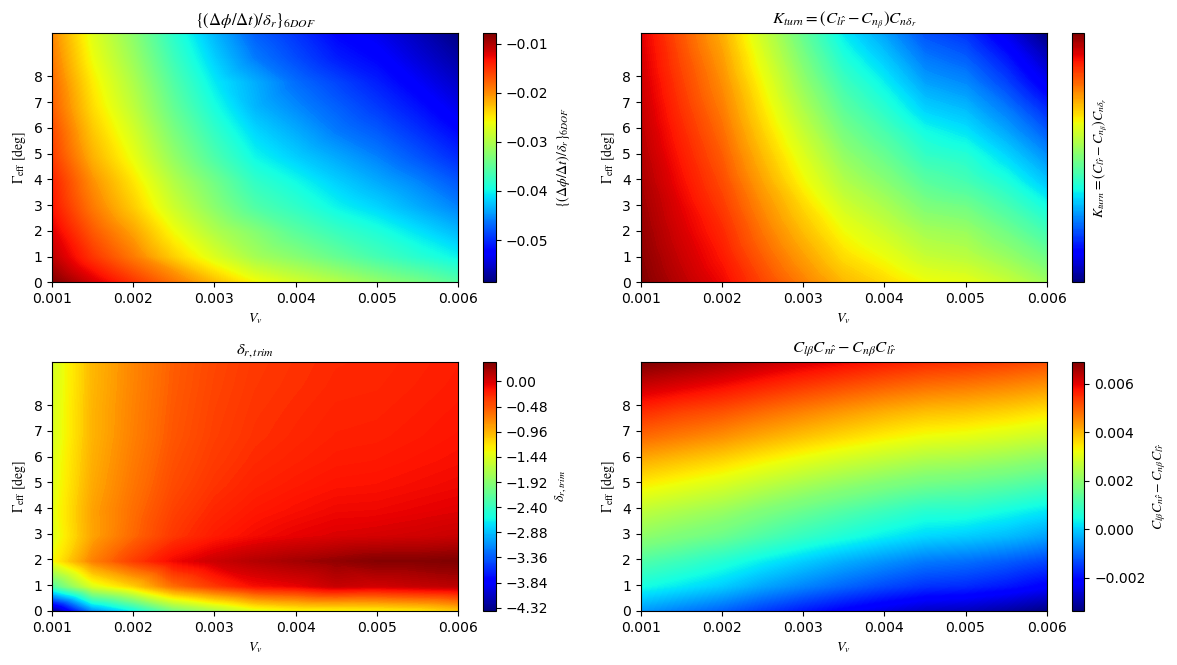

In [36]:

metric_panels = [
    ("sixdof_roll_response_phi_rate_per_delta_r", None),
    # ("linear_roll_response_phi_rate_per_delta_r", None),
    ('simple_turn_rate', None),
    # ('simple_turn_rate_full', None),
    ('turn_trim_delta_r', None),
    # ('simple_turn_trim_delta_r_per_beta', None),
    # ('turn_trim_beta', None),
    ('spiral_margin', None),
]

# fig, axes = plt.subplots(1, len(metric_panels), figsize=(4*len(metric_panels), 3), sharex=True, sharey=True)
fig, axes = plt.subplots(2, 2, figsize=(12, 9*3/4), sharex=False, sharey=False)
for ax, (column, label) in zip(axes.flat, metric_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_metrics")
plt.show()

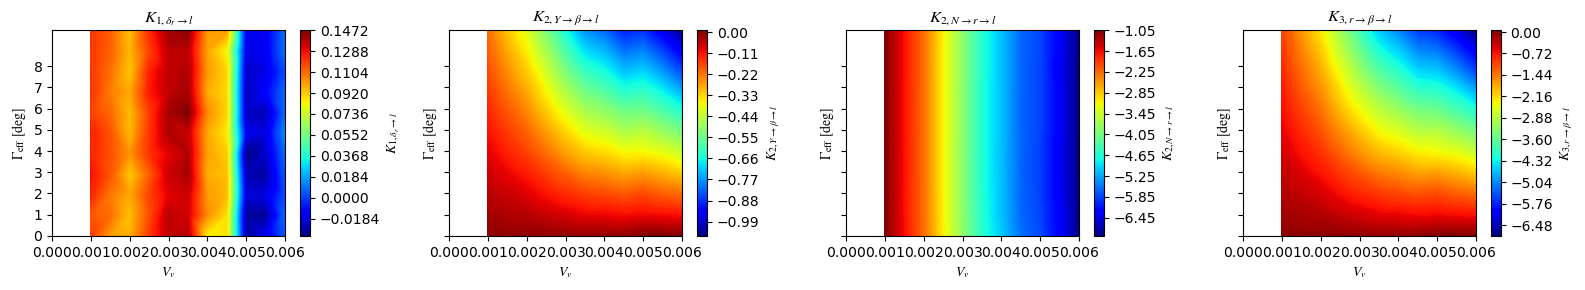

In [29]:

metric_panels = [
    ('simple_K1_direct_roll', None),
    ('simple_K2_sideforce_dihedral', None),
    ('simple_K2_yawrate_roll', None),
    ('simple_K3_yawrate_to_beta_dihedral', None),
]

fig, axes = plt.subplots(1, len(metric_panels), figsize=(4*len(metric_panels), 3), sharex=True, sharey=True)
for ax, (column, label) in zip(axes.flat, metric_panels):
    plot_vv_gamma_contour_panel(df, column, ax=ax, label=label, **PANEL_KWARGS)

save_figure(fig, "vv_gamma_rudder_turn_metrics")
plt.show()

## 9. 出力ファイル

生成した図は `vv_gamma_chart_plots/` に保存される。

In [30]:
for path in sorted(output_dir.glob("vv_gamma_*")):
    print(path)

vv_gamma_chart_plots\vv_gamma_base_coefficients.pdf
vv_gamma_chart_plots\vv_gamma_base_coefficients.png
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.pdf
vv_gamma_chart_plots\vv_gamma_lateral_derivatives.png
vv_gamma_chart_plots\vv_gamma_longitudinal_derivatives.pdf
vv_gamma_chart_plots\vv_gamma_longitudinal_derivatives.png
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.pdf
vv_gamma_chart_plots\vv_gamma_rudder_turn_metrics.png


## 横転6DOF

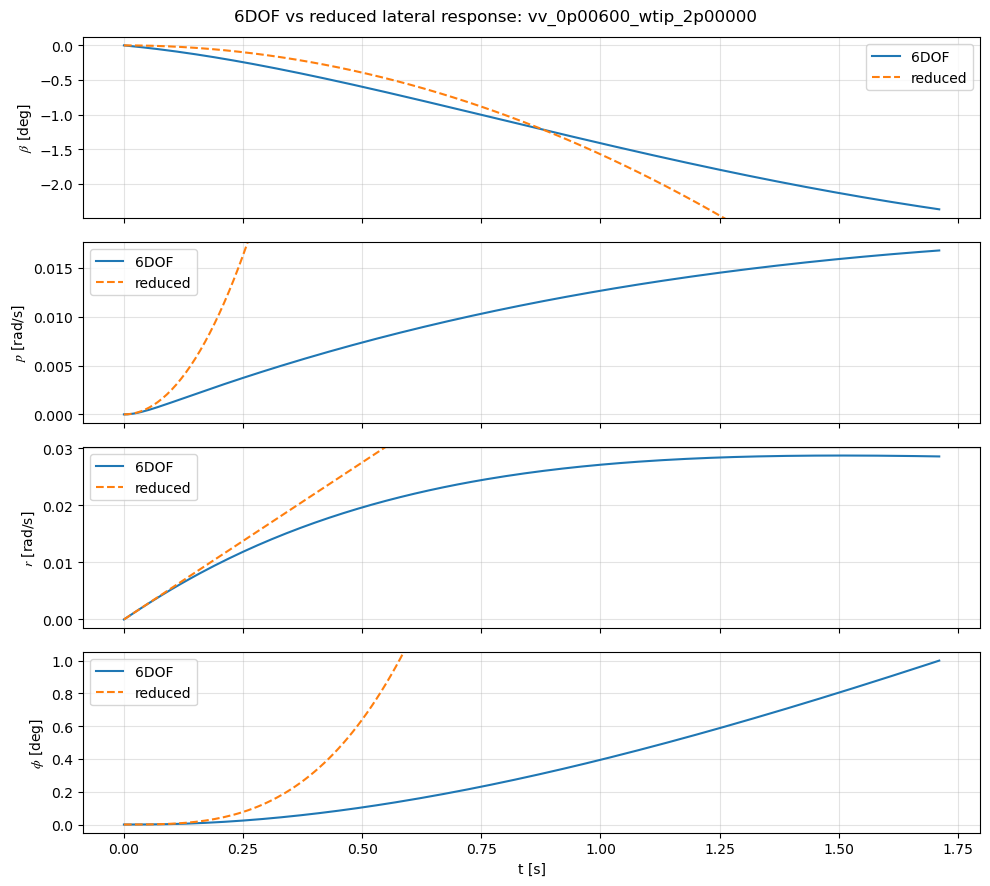

{'fig': <Figure size 1000x900 with 4 Axes>,
 'axes': array([<Axes: ylabel='$\\beta$ [deg]'>, <Axes: ylabel='$p$ [rad/s]'>,
        <Axes: ylabel='$r$ [rad/s]'>,
        <Axes: xlabel='t [s]', ylabel='$\\phi$ [deg]'>], dtype=object),
 'sixdof_history':          time          u         v         w             p             q  \
 0    0.000000  10.000000  0.000000  0.000000  0.000000e+00  0.000000e+00   
 1    0.000998  10.000000 -0.000116  0.000308 -6.056682e-07 -2.756939e-07   
 2    0.007744  10.000007 -0.000909  0.002336  9.594207e-06 -1.584512e-05   
 3    0.014447  10.000024 -0.001716  0.004264  4.100657e-05 -5.271042e-05   
 4    0.021438  10.000053 -0.002578  0.006184  9.202635e-05 -1.107435e-04   
 ..        ...        ...       ...       ...           ...           ...   
 171  1.680207  10.080017 -0.411916  0.022644  1.667096e-02 -2.088363e-03   
 172  1.690207  10.080646 -0.413769  0.022476  1.670796e-02 -2.060867e-03   
 173  1.700207  10.081277 -0.415603  0.022308  1.674441e

In [31]:

from src.RollRudderGain import (
    plot_vv_gamma_row_6dof_vs_reduced_response,
)

plot_vv_gamma_row_6dof_vs_reduced_response(
    metrics=Path(f"vv_gamma_metrics.csv"),
    row_index=120,
    mass=mass,
    inertia=inertia,
    rho=None,
    control_map=None,
    history_path_column="sixdof_history_csv_path",
    recompute_6dof_if_missing=True,
    plot_path=None,
    show=True,
    degrees=True,
    max_step=0.01,
    rtol=1.0e-8,
    atol=1.0e-10,
    include_roll_damping=False,
    include_yaw_damping=False,
)

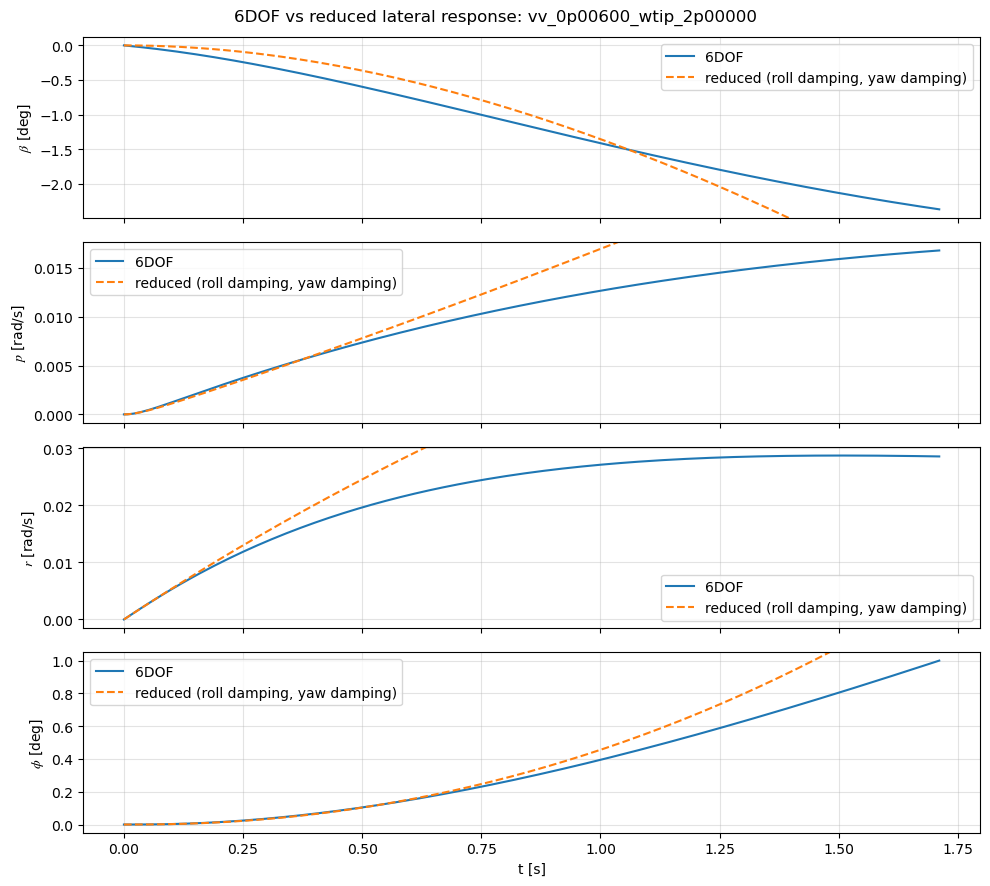

{'fig': <Figure size 1000x900 with 4 Axes>,
 'axes': array([<Axes: ylabel='$\\beta$ [deg]'>, <Axes: ylabel='$p$ [rad/s]'>,
        <Axes: ylabel='$r$ [rad/s]'>,
        <Axes: xlabel='t [s]', ylabel='$\\phi$ [deg]'>], dtype=object),
 'sixdof_history':          time          u         v         w             p             q  \
 0    0.000000  10.000000  0.000000  0.000000  0.000000e+00  0.000000e+00   
 1    0.000998  10.000000 -0.000116  0.000308 -6.056682e-07 -2.756939e-07   
 2    0.007744  10.000007 -0.000909  0.002336  9.594207e-06 -1.584512e-05   
 3    0.014447  10.000024 -0.001716  0.004264  4.100657e-05 -5.271042e-05   
 4    0.021438  10.000053 -0.002578  0.006184  9.202635e-05 -1.107435e-04   
 ..        ...        ...       ...       ...           ...           ...   
 171  1.680207  10.080017 -0.411916  0.022644  1.667096e-02 -2.088363e-03   
 172  1.690207  10.080646 -0.413769  0.022476  1.670796e-02 -2.060867e-03   
 173  1.700207  10.081277 -0.415603  0.022308  1.674441e

In [32]:

from src.RollRudderGain import (
    plot_vv_gamma_row_6dof_vs_reduced_response,
)

plot_vv_gamma_row_6dof_vs_reduced_response(
    metrics=Path(f"vv_gamma_metrics.csv"),
    row_index=120,
    mass=mass,
    inertia=inertia,
    rho=None,
    control_map=None,
    history_path_column="sixdof_history_csv_path",
    recompute_6dof_if_missing=True,
    plot_path=None,
    show=True,
    degrees=True,
    max_step=0.01,
    rtol=1.0e-8,
    atol=1.0e-10,
    include_roll_damping=True,
    include_yaw_damping=True,
)